# ML Pipeline â€” ETL-sourced Training Data

End-to-end training pipeline that loads fully prepared features directly from the **SQLite database** maintained by `etl_demand.py`, instead of re-fetching and re-engineering raw data on every run.

Four models are trained and saved:

| Model | Objective | Purpose | Saved as |
| LightGBM | MAE (default) | Best-estimate forecast | `best_lgbm_model_bayesian_etl.pkl` |
| LightGBM conservative | Quantile Î±=0.95 | Minimise under-prediction risk | `best_lgbm_model_bayesian_conservative_etl.pkl` |
| XGBoost | squared-error | Best-estimate forecast | `best_xgb_model_bayesian_etl.pkl` |
| XGBoost conservative | Quantile Î±=0.95 | Minimise under-prediction risk | `best_xgb_model_bayesian_conservative_etl.pkl` |

All hyperparameters are tuned with `BayesSearchCV` using time-series-aware 5-fold cross-validation (`TimeSeriesSplit`).  
The `_etl` postfix distinguishes these models from those trained in the legacy CSV-based pipeline (`07_complete_ml_pipeline.ipynb`).

In [ ]:
import sys
import os

# Add the src directory to the system path to allow importing custom modules
sys.path.insert(0, os.path.abspath('../src'))

import warnings
warnings.filterwarnings('ignore')

# Enable autoreload to automatically reload modules when they are edited
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import pandas as pd

from fetch_demand_data import *
from train_predict_model import *

# Set a consistent style for all plots
import matplotlib.pyplot as plt
plt.rcParams.update({
    'axes.grid':      True,
    'grid.color':     '#DCDCDC',
    'grid.linewidth': 0.5,
    'grid.linestyle': '-',
    'axes.axisbelow': True,
    'axes.facecolor': 'white',
    'font.family':    'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titlepad':  13,
    'axes.labelsize': 10,
    'axes.labelpad':  8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'legend.frameon':    True,
    'legend.facecolor':  'white',
    'legend.edgecolor':  '#DCDCDC',
    'legend.framealpha': 1.0,
    'legend.fontsize':   9,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Update & Load Data from Database

`update_database()` is idempotent:
- **First run** â€” seeds both tables from the Kaggle CSV and the Open-Meteo API.
- **Subsequent runs** â€” only fills the gap between the last stored timestamp and yesterday; usually completes in seconds.

After the update, `load_combined_data()` reads the pre-joined `energy_weather_combined` view â€” all engineered features are already stored in the DB, so no re-computation is needed here.

Two columns are dropped before training because they are informational, not predictive:
- `smard_forecast_mwh` â€” SMARD official forecast, kept in the DB for actual-vs-forecast comparison
- `data_source` â€” provenance label (`'kaggle'` / `'smard'`)

The target column `energy_demand_mwh` is renamed to `EnergyDemand` to match the existing pipeline conventions used throughout the other notebooks.

In [4]:
from etl_demand import update_database, get_connection, load_combined_data

# Ensure the database is up to date â€” no-op if already current
update_database()

# Load the pre-joined, feature-engineered dataset from the DB view
conn = get_connection()
df_raw = load_combined_data(conn)
conn.close()

# Drop non-predictive columns; rename target to match existing pipeline conventions
df_for_modeling = (
    df_raw
    .drop(columns=['smard_forecast_mwh', 'data_source'], errors='ignore')
    .rename(columns={'energy_demand_mwh': 'EnergyDemand'})
    .dropna()
    .reset_index(drop=True)
)

print(f"Dataset : {len(df_for_modeling):,} rows")
print(f"Range   : {df_for_modeling['time'].min().date()} â€“ {df_for_modeling['time'].max().date()}")
print(f"Features: {df_for_modeling.shape[1] - 1}  |  Target: EnergyDemand")
display(df_for_modeling.head(3))

Database ready: C:\Data\Stackfuel-Unterricht\Portfolio\Europe_Electricity_Load\workspace_energy_demand\db\energy_demand.db

Current data status:
  energy         :  64672 rows | max: 2026-05-25T23:00:00+0200 | up-to-date: True
  weather        :  64825 rows | max: 2026-05-26T01:00:00+0200 | up-to-date: True

[Energy] Up to date â€” nothing to do.

[Weather] Up to date â€” nothing to do.

Done.
  energy_demand : 64672 rows | max: 2026-05-25T23:00:00+0200
  weather       : 64825 rows | max: 2026-05-26T01:00:00+0200
Dataset : 64,672 rows
Range   : 2019-01-08 â€“ 2026-05-25
Features: 27  |  Target: EnergyDemand


,time,EnergyDemand,year,hour,weekday,month,is_weekend,is_holiday,holiday_ratio,is_workday,...,rain,snowfall,wind_speed_10m,shortwave_radiation,apparent_temperature_lag_24h,apparent_temperature_rolling_mean_24h,shortwave_radiation_0m_lag_24h,shortwave_radiation_0m_rolling_mean_24h,heating_degree,cooling_degree
0,2019-01-08 01:00:00+01:00,52754.4700,2019,1,1,1,0,0,0.0,1,...,0.497775,0.000000,23.098559,0.0,-1.026161,0.200133,0.0,10.766481,17.925307,0.0
1,2019-01-08 02:00:00+01:00,51889.2625,2019,2,1,1,0,0,0.0,1,...,0.518651,0.023420,25.225514,0.0,-0.669110,0.246002,0.0,10.766481,18.115502,0.0
2,2019-01-08 03:00:00+01:00,52475.5475,2019,3,1,1,0,0,0.0,1,...,0.561141,0.046841,25.289731,0.0,-0.652509,0.269069,0.0,10.766481,18.155768,0.0


In [3]:
df_for_modeling.columns

Index(['time', 'EnergyDemand', 'year', 'hour', 'weekday', 'month',
       'is_weekend', 'is_holiday', 'holiday_ratio', 'is_workday',
       'is_bridge_day', 'holiday_weight', 'is_pandemic_time',
       'energy_demand_lag_24h', 'energy_demand_lag_168h',
       'energy_demand_rolling_mean_24h', 'energy_demand_rolling_mean_168h',
       'apparent_temperature', 'rain', 'snowfall', 'wind_speed_10m',
       'shortwave_radiation', 'apparent_temperature_lag_24h',
       'apparent_temperature_rolling_mean_24h',
       'shortwave_radiation_0m_lag_24h',
       'shortwave_radiation_0m_rolling_mean_24h', 'heating_degree',
       'cooling_degree'],
      dtype='str')

## 2. Train / Test Split

A **chronological split at 2025-01-01** is used for all four models:
- **Train** â€” 2019-01-08 to 2024-12-31
- **Test** â€” 2025-01-01 onwards (unseen future data)

This mirrors real-world deployment: the model is trained on historical patterns and evaluated on data it has never seen.

The split date is passed as a tz-aware `pd.Timestamp` because the `time` column retains `Europe/Berlin` timezone information from the database.

In [12]:
SPLIT_DATE = pd.Timestamp('2025-01-01', tz='Europe/Berlin')

features_train, target_train, features_test, target_test = train_test_split_by_date(
    df_for_modeling,
    date_column='time',
    target_column='EnergyDemand',
    split_date=SPLIT_DATE,
)

print(f"Train : {len(features_train):,} rows  ({features_train.shape[1]} features)")
print(f"Test  : {len(features_test):,} rows")

Train : 52,433 rows  (26 features)
Test  : 12,239 rows


## 3. LightGBM â€” Standard (Best-Estimate)

LightGBM is tuned with `BayesSearchCV` over a continuous hyperparameter space using `TimeSeriesSplit(n_splits=5)`. The default `objective='regression'` minimises MAE, producing an unbiased best-estimate forecast. Tree-based models do not require feature scaling, so no preprocessor pipeline is needed.

| Parameter | Search range |
|---|---|
| `n_estimators` | 50 â€“ 500 |
| `learning_rate` | 0.01 â€“ 0.30 |
| `max_depth` | 3 â€“ 15 |

In [ ]:
!uv add scikit-optimize

from skopt import BayesSearchCV

In [5]:
from lightgbm import LGBMRegressor
from skopt import BayesSearchCV

param_lgbm = {
    'n_estimators':  (50, 500),
    'learning_rate': (0.01, 0.3),
    'max_depth':     (3, 15),
}

model_lgbm = LGBMRegressor(random_state=42, force_col_wise=True)
best_model_lgbm, best_params_lgbm = tune_model_bayesian(
    model_pipeline=model_lgbm,
    in_param_bayes=param_lgbm,
    in_features_train=features_train,
    in_target_train=target_train,
)
print(f"Best hyperparameters: {best_params_lgbm}")
print()

pred_lgbm = best_model_lgbm.predict(features_test)
print_scores('LightGBM', target_test, pred_lgbm)

save_model_to_pickle(best_model_lgbm, '../models/best_lgbm_model_bayesian_etl.pkl')
print("Saved â†’ ../models/best_lgbm_model_bayesian_etl.pkl")

[LightGBM] [Info] Total Bins 3900
[LightGBM] [Info] Number of data points in the train set: 52433, number of used features: 26
[LightGBM] [Info] Start training from score 54984.686601
Best hyperparameters: OrderedDict({'learning_rate': 0.09418373200125837, 'max_depth': 8, 'n_estimators': 463})

-------------------- scoring --------------------
model                  MAE       RMSE       RÂ²
LightGBM            1249.75    1612.12     0.97
Saved â†’ ../models/best_lgbm_model_bayesian_etl.pkl


## 4. XGBoost â€” Standard (Best-Estimate)

XGBoost is tuned with the same Bayesian optimisation approach. The search space is extended with subsampling and column-sampling parameters that help control overfitting on the large training set.

| Parameter | Search range |
|---|---|
| `n_estimators` | 50 â€“ 500 |
| `max_depth` | 3 â€“ 15 |
| `learning_rate` | 0.01 â€“ 0.30 |
| `subsample` | 0.5 â€“ 1.0 |
| `colsample_bytree` | 0.5 â€“ 1.0 |

In [6]:
from xgboost import XGBRegressor

param_xgb = {
    'n_estimators':     (50, 500),
    'max_depth':        (3, 15),
    'learning_rate':    (0.01, 0.3),
    'subsample':        (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
}

model_xgb = XGBRegressor(random_state=42)
best_model_xgb, best_params_xgb = tune_model_bayesian(
    model_pipeline=model_xgb,
    in_param_bayes=param_xgb,
    in_features_train=features_train,
    in_target_train=target_train,
)
print(f"Best hyperparameters: {best_params_xgb}")
print()

pred_xgb = best_model_xgb.predict(features_test)
print_scores('XGBoost', target_test, pred_xgb)

save_model_to_pickle(best_model_xgb, '../models/best_xgb_model_bayesian_etl.pkl')
print("Saved â†’ ../models/best_xgb_model_bayesian_etl.pkl")

Best hyperparameters: OrderedDict({'colsample_bytree': 0.6508034623351452, 'learning_rate': 0.06915031630617872, 'max_depth': 8, 'n_estimators': 142, 'subsample': 0.6197843911900174})

-------------------- scoring --------------------
model                  MAE       RMSE       RÂ²
XGBoost             1202.46    1553.70     0.97
Saved â†’ ../models/best_xgb_model_bayesian_etl.pkl


## 5. Conservative Models â€” Quantile Regression (Î± = 0.95)

Grid operators prefer **over-provisioning** to under-provisioning: the cost of having too much capacity is far lower than the cost of a shortage. Conservative models use **quantile regression** at Î± = 0.95, targeting the 95th percentile of the conditional demand distribution.

| Framework | Setting |
|---|---|
| LightGBM | `objective='quantile'`, `alpha=0.95` |
| XGBoost | `objective='reg:quantileerror'`, `quantile_alpha=0.95` |

At Î± = 0.95 the model is calibrated to exceed actual demand in ~95% of hours. The trade-off is a positive mean bias (systematic over-prediction). The **conservatism check** after each model quantifies this on the test set.

The same hyperparameter search spaces (`param_lgbm`, `param_xgb`) are reused â€” only the loss function changes.

In [7]:
# â”€â”€ LightGBM conservative â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
model_lgbm_conservative = LGBMRegressor(
    objective='quantile',
    alpha=0.95,   # the higher the alpha, the more conservative
    random_state=42,
    force_col_wise=True,
)
best_model_lgbm_conservative, best_params_lgbm_conservative = tune_model_bayesian(
    model_pipeline=model_lgbm_conservative,
    in_param_bayes=param_lgbm,
    in_features_train=features_train,
    in_target_train=target_train,
)
print(f"Best hyperparameters: {best_params_lgbm_conservative}")
print()

pred_lgbm_conservative = best_model_lgbm_conservative.predict(features_test)
print_scores('LightGBM conservative', target_test, pred_lgbm_conservative)

save_model_to_pickle(best_model_lgbm_conservative, '../models/best_lgbm_model_bayesian_conservative_etl.pkl')
print("Saved â†’ ../models/best_lgbm_model_bayesian_conservative_etl.pkl")

# Conservatism check â€” fraction of hours where prediction >= actual (target: ~95%)
coverage_lgbm = (pred_lgbm_conservative >= target_test.values).mean()
overpred_lgbm = pred_lgbm_conservative - target_test.values
print(f"\nConservatism check  (target: ~95%)")
print(f"  Coverage (pred >= actual) : {coverage_lgbm:.1%}")
print(f"  Mean bias                 : {overpred_lgbm.mean():+,.0f} MWh")
print(f"  Under-predictions         : {(overpred_lgbm < 0).sum()} / {len(overpred_lgbm)} hours")

[LightGBM] [Info] Total Bins 3900
[LightGBM] [Info] Number of data points in the train set: 52433, number of used features: 26
[LightGBM] [Info] Start training from score 70902.382812
Best hyperparameters: OrderedDict({'learning_rate': 0.2995904208215501, 'max_depth': 15, 'n_estimators': 412})

-------------------- scoring --------------------
model                  MAE       RMSE       RÂ²
LightGBM conservative    1741.55    2293.85     0.94
Saved â†’ ../models/best_lgbm_model_bayesian_conservative_etl.pkl

Conservatism check  (target: ~95%)
  Coverage (pred >= actual) : 77.6%
  Mean bias                 : +1,298 MWh
  Under-predictions         : 2747 / 12239 hours


In [8]:
# â”€â”€ XGBoost conservative â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
model_xgb_conservative = XGBRegressor(
    objective='reg:quantileerror',
    quantile_alpha=0.95,   # the higher the alpha, the more conservative
    random_state=42,
)
best_model_xgb_conservative, best_params_xgb_conservative = tune_model_bayesian(
    model_pipeline=model_xgb_conservative,
    in_param_bayes=param_xgb,
    in_features_train=features_train,
    in_target_train=target_train,
)
print(f"Best hyperparameters: {best_params_xgb_conservative}")
print()

pred_xgb_conservative = best_model_xgb_conservative.predict(features_test)
print_scores('XGBoost conservative', target_test, pred_xgb_conservative)

save_model_to_pickle(best_model_xgb_conservative, '../models/best_xgb_model_bayesian_conservative_etl.pkl')
print("Saved â†’ ../models/best_xgb_model_bayesian_conservative_etl.pkl")

# Conservatism check
coverage_xgb = (pred_xgb_conservative >= target_test.values).mean()
overpred_xgb = pred_xgb_conservative - target_test.values
print(f"\nConservatism check  (target: ~95%)")
print(f"  Coverage (pred >= actual) : {coverage_xgb:.1%}")
print(f"  Mean bias                 : {overpred_xgb.mean():+,.0f} MWh")
print(f"  Under-predictions         : {(overpred_xgb < 0).sum()} / {len(overpred_xgb)} hours")

Best hyperparameters: OrderedDict({'colsample_bytree': 0.5, 'learning_rate': 0.13657638776412223, 'max_depth': 15, 'n_estimators': 500, 'subsample': 0.5})

-------------------- scoring --------------------
model                  MAE       RMSE       RÂ²
XGBoost conservative    1668.32    2181.62     0.95
Saved â†’ ../models/best_xgb_model_bayesian_conservative_etl.pkl

Conservatism check  (target: ~95%)
  Coverage (pred >= actual) : 68.0%
  Mean bias                 : +899 MWh
  Under-predictions         : 3916 / 12239 hours


## 6. Learning Curves

Learning curves compare training MAE vs. cross-validation MAE as the training set size grows. They help diagnose:
- **Overfitting** â€” large persistent gap between train and CV score
- **Underfitting** â€” both scores converge at a high MAE
- **Good fit** â€” the gap closes as training data increases

The conservative models are expected to show higher absolute MAE than their standard counterparts, because quantile loss at Î±=0.95 penalises under-predictions much more heavily than over-predictions, yielding a systematically biased but intentionally conservative estimator.

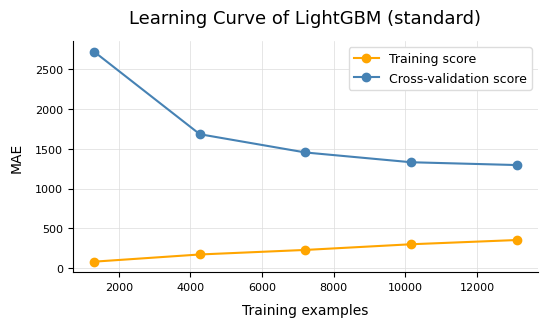

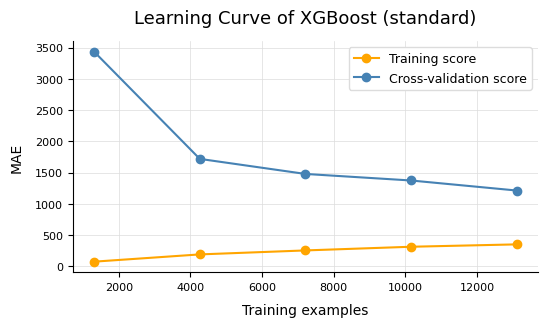

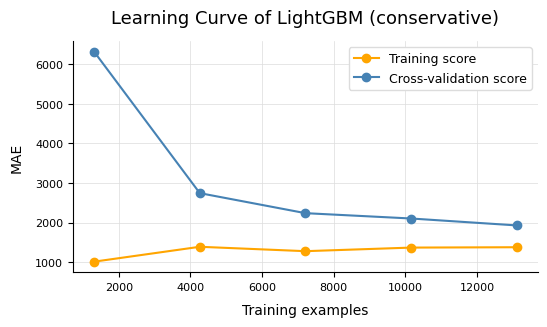

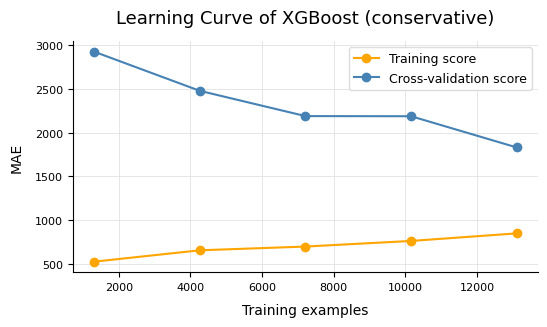

In [9]:
plot_learning_curve(best_model_lgbm,              'LightGBM (standard)',     features_train, target_train)
plot_learning_curve(best_model_xgb,               'XGBoost (standard)',      features_train, target_train)
plot_learning_curve(best_model_lgbm_conservative, 'LightGBM (conservative)', features_train, target_train)
plot_learning_curve(best_model_xgb_conservative,  'XGBoost (conservative)',  features_train, target_train)